# 02 — Veri Ön İşleme
labels.csv → temizle → TARGET_GENRES → stratified split → train/val/test.csv + mlb.pkl

In [1]:
from pathlib import Path

# --- Yerel ---
CODE_ROOT = Path("../")
DATA_ROOT = Path("../")

# --- Colab ---
# from google.colab import drive
# drive.mount('/content/drive')
# CODE_ROOT = Path('/content/drive/MyDrive/film-genre-project')
# DATA_ROOT = Path('/content/drive/MyDrive/film-genre-project-data')

POSTERS_DIR  = DATA_ROOT / "posters"
LABELS_CSV   = DATA_ROOT / "labels.csv"
TRAIN_CSV    = DATA_ROOT / "train.csv"
VAL_CSV      = DATA_ROOT / "val.csv"
TEST_CSV     = DATA_ROOT / "test.csv"
MLB_PKL      = DATA_ROOT / "mlb.pkl"

print("LABELS_CSV exists:", LABELS_CSV.exists())
print("POSTERS_DIR exists:", POSTERS_DIR.exists())

LABELS_CSV exists: True
POSTERS_DIR exists: True


In [2]:
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from sklearn.preprocessing import MultiLabelBinarizer

## 1. labels.csv yükle ve postersiz satırları düşür

In [3]:
df = pd.read_csv(LABELS_CSV, dtype={"tmdb_id": str})
print(f"Ham satır sayısı: {len(df):,}")

# genres sütununu listeye çevir
df["genres"] = df["genres"].fillna("").apply(
    lambda x: [g.strip() for g in x.split("|") if g.strip()]
)

# Boş genres olan satırları düşür
before = len(df)
df = df[df["genres"].map(len) > 0].reset_index(drop=True)
print(f"Türsüz satır düşürüldü: {before - len(df):,}")

# Poster dosyası olmayanları düşür
before = len(df)
df = df[df["tmdb_id"].apply(lambda i: (POSTERS_DIR / f"{i}.jpg").exists())].reset_index(drop=True)
print(f"Postersiz satır düşürüldü: {before - len(df):,}")
print(f"Kalan satır sayısı: {len(df):,}")

Ham satır sayısı: 12,235
Türsüz satır düşürüldü: 0
Postersiz satır düşürüldü: 28
Kalan satır sayısı: 12,207


## 2. Tür dağılımı ve TARGET_GENRES

Tüm türler ve film sayıları:
Drama              5539
Comedy             4473
Thriller           2529
Action             2227
Romance            2071
Crime              1835
Adventure          1558
Horror             1401
Science Fiction    1146
Family             1057
Fantasy             960
Mystery             830
Animation           656
Documentary         593
History             532
Music               487
War                 397
TV Movie            368
Western             260


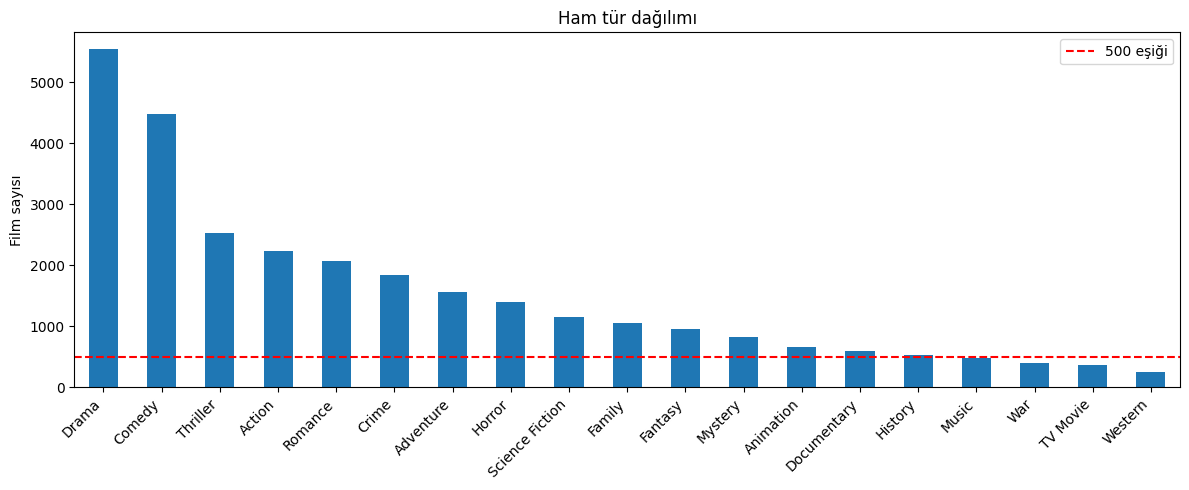

In [4]:
from collections import Counter

all_genres = [g for genres in df["genres"] for g in genres]
counts = pd.Series(Counter(all_genres)).sort_values(ascending=False)

print("Tüm türler ve film sayıları:")
print(counts.to_string())

fig, ax = plt.subplots(figsize=(12, 5))
counts.plot(kind="bar", ax=ax)
ax.axhline(500, color="red", linestyle="--", label="500 eşiği")
ax.set_title("Ham tür dağılımı")
ax.set_ylabel("Film sayısı")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [5]:
MIN_COUNT = 500
TARGET_GENRES = sorted(counts[counts >= MIN_COUNT].index.tolist())
print(f"TARGET_GENRES ({len(TARGET_GENRES)} tür, eşik={MIN_COUNT}):")
for g in TARGET_GENRES:
    print(f"  {g}: {counts[g]:,}")

TARGET_GENRES (15 tür, eşik=500):
  Action: 2,227
  Adventure: 1,558
  Animation: 656
  Comedy: 4,473
  Crime: 1,835
  Documentary: 593
  Drama: 5,539
  Family: 1,057
  Fantasy: 960
  History: 532
  Horror: 1,401
  Mystery: 830
  Romance: 2,071
  Science Fiction: 1,146
  Thriller: 2,529


## 3. TARGET_GENRES filtrele

In [6]:
target_set = set(TARGET_GENRES)

# Her filmin yalnızca hedef türleri tut
df["genres"] = df["genres"].apply(lambda gs: [g for g in gs if g in target_set])

# Hiçbir hedef türü kalmayan satırları düşür
before = len(df)
df = df[df["genres"].map(len) > 0].reset_index(drop=True)
print(f"Hedef tür dışı satır düşürüldü: {before - len(df):,}")
print(f"Final satır sayısı: {len(df):,}")

Hedef tür dışı satır düşürüldü: 117
Final satır sayısı: 12,090


## 4. MultiLabelBinarizer

In [7]:
mlb = MultiLabelBinarizer(classes=TARGET_GENRES)
Y = mlb.fit_transform(df["genres"])
print(f"Y shape: {Y.shape}  — ({len(df)} film, {len(TARGET_GENRES)} tür)")
print("Sınıflar:", mlb.classes_)

with open(MLB_PKL, "wb") as f:
    pickle.dump(mlb, f)
print(f"mlb.pkl kaydedildi → {MLB_PKL}")

Y shape: (12090, 15)  — (12090 film, 15 tür)
Sınıflar: ['Action' 'Adventure' 'Animation' 'Comedy' 'Crime' 'Documentary' 'Drama'
 'Family' 'Fantasy' 'History' 'Horror' 'Mystery' 'Romance'
 'Science Fiction' 'Thriller']
mlb.pkl kaydedildi → ..\mlb.pkl


## 5. Stratified 70/15/15 split

In [8]:
X_idx = np.arange(len(df))

# %70 train — %30 geçici
mss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, temp_idx = next(mss.split(X_idx, Y))

# %30 → %15 val + %15 test
mss2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_rel, test_rel = next(mss2.split(X_idx[temp_idx], Y[temp_idx]))
val_idx  = temp_idx[val_rel]
test_idx = temp_idx[test_rel]

print(f"Train: {len(train_idx):,}  Val: {len(val_idx):,}  Test: {len(test_idx):,}")

Train: 8,466  Val: 1,818  Test: 1,806


In [9]:
# genres listesini pipe-ayrılmış stringe geri dönüştür (CSV için)
df_save = df.copy()
df_save["genres"] = df_save["genres"].apply("|".join)

df_save.iloc[train_idx].to_csv(TRAIN_CSV, index=False)
df_save.iloc[val_idx].to_csv(VAL_CSV,   index=False)
df_save.iloc[test_idx].to_csv(TEST_CSV,  index=False)

print(f"Kaydedildi:\n  {TRAIN_CSV}\n  {VAL_CSV}\n  {TEST_CSV}")

Kaydedildi:
  ..\train.csv
  ..\val.csv
  ..\test.csv


## 6. Split dağılımını görselleştir

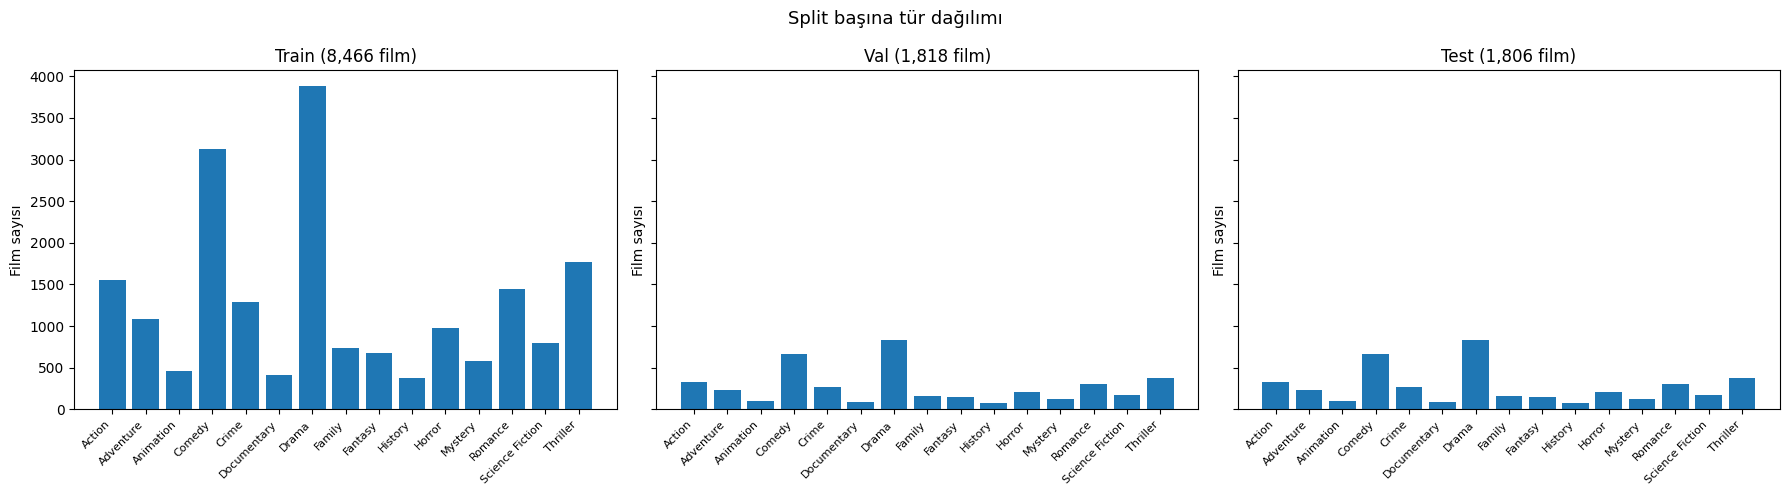


Per-class split oranları (train/val/test):
  Action               1559 /  334 /  334  (70% / 15% / 15%)
  Adventure            1091 /  234 /  233  (70% / 15% / 15%)
  Animation             459 /   99 /   98  (70% / 15% / 15%)
  Comedy               3131 /  671 /  671  (70% / 15% / 15%)
  Crime                1285 /  275 /  275  (70% / 15% / 15%)
  Documentary           415 /   89 /   89  (70% / 15% / 15%)
  Drama                3877 /  831 /  831  (70% / 15% / 15%)
  Family                740 /  159 /  158  (70% / 15% / 15%)
  Fantasy               672 /  144 /  144  (70% / 15% / 15%)
  History               372 /   80 /   80  (70% / 15% / 15%)
  Horror                981 /  210 /  210  (70% / 15% / 15%)
  Mystery               581 /  125 /  124  (70% / 15% / 15%)
  Romance              1450 /  311 /  310  (70% / 15% / 15%)
  Science Fiction       802 /  172 /  172  (70% / 15% / 15%)
  Thriller             1770 /  380 /  379  (70% / 15% / 15%)


In [10]:
splits = {
    "Train": Y[train_idx],
    "Val":   Y[val_idx],
    "Test":  Y[test_idx],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, (name, mat) in zip(axes, splits.items()):
    counts_split = mat.sum(axis=0)
    ax.bar(TARGET_GENRES, counts_split)
    ax.set_title(f"{name} ({len(mat):,} film)")
    ax.set_ylabel("Film sayısı")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
plt.suptitle("Split başına tür dağılımı", fontsize=13)
plt.tight_layout()
plt.show()

print("\nPer-class split oranları (train/val/test):")
for i, g in enumerate(TARGET_GENRES):
    tr = Y[train_idx, i].sum()
    va = Y[val_idx, i].sum()
    te = Y[test_idx, i].sum()
    total = tr + va + te
    print(f"  {g:20s} {tr:4d} / {va:4d} / {te:4d}  ({tr/total:.0%} / {va/total:.0%} / {te/total:.0%})")